## Identifying Pick-and-Roll and Pick-and-Pop Actions throughout NBA Games ##

In this notebook, we will be taking raw SportVU NBA Tracking Data from the 2015-16 NBA season, which is combined with play-by-play data to devise a method to identify pick-and-roll and pick-and-pop actions across NBA games. The data used comes from the following repository: `https://huggingface.co/datasets/dcayton/nba_tracking_data_15_16`

The use-case of this can be for more efficient scouting and could be applied to other events with other outlined criteria in a similar fashion. This builds on prior work that simply identified on-ball screens, and this work looks to expand on that work by identifying specific actions that exist and differentiate the purpose of those ball screens.

In [2]:
!pip install py7zr

from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/stat663_huggingface_project

Mounted at /content/drive
[Errno 2] No such file or directory: '/content/drive/MyDrive/stat663_huggingface_project'
/content


In [3]:
from datasets import load_dataset
dataset = load_dataset("dcayton/nba_tracking_data_15_16", name = "tiny", trust_remote_code=True)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'dcayton/nba_tracking_data_15_16' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'dcayton/nba_tracking_data_15_16' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your sessi

README.md: 0.00B [00:00, ?B/s]

nba_tracking_data_15_16.py: 0.00B [00:00, ?B/s]

RuntimeError: Dataset scripts are no longer supported, but found nba_tracking_data_15_16.py

### Pre-processing ###
Before any modeling, a significant amount of data processing must be done. Since we are searching for pick-and-roll and pick-and-pop actions, we must filter the events through a candidate algorithm, so that we can create a more efficient training set.

Prior to this though, we need to shift the left-to-right coordinate data all to one direction representing the half-court for the team in possession. This helps us standardize the later search criteria. Also, we can narrow the actions we will classify to only include actions that correspond to a made shot, missed shot, turnover, and foul, as these are all offensive plays that may include a desired action. A defensive play like a rebound or block will not be helpful (and also may crossover with a shot anyways). Likewise, a technical event, such as a substitution or foul shot, is not helpful as the ball is not in play.

After filtering and rotating, a criteria to identify potential PNR/PNP situations is devised.
1. ID ball-handler
2. ID on-ball defender
3. ID screener
4. ID if a moment is a ball-screen
5. ID if a ball-screen continues for 8 or more frames (1/3 of a second)

Once the candidates are filtered, they can be saved in a separate generator to be worked with exclusively.

In [ ]:
def left_basket(moment):
  """
  This function takes a moment in the game and returns if the ball is in the left basket.
  """
  return (3.5 <= moment['ball_coordinates']['x'] <= 6) and (24 <= moment['ball_coordinates']['y'] <= 26)

def right_basket(moment):
  """
  This function takes a moment in the game and returns if the ball is in the right basket.
  """
  return (88 <= moment['ball_coordinates']['x'] <= 90.5) and (24 <= moment['ball_coordinates']['y'] <= 26)

# using find_actions() criteria from https://etd.ohiolink.edu/acprod/odb_etd/ws/send_file/send?accession=csu14943636475232&disposition=inline
def locate_ballhandler(moment, poss_team_id):
  """
  This function takes a moment in the game as well as the team ID in possession.
  It returns the ID of the presumed ball-handler (player closest to the ball).
  The outline of this function is based on criteria from 'https://etd.ohiolink.edu/acprod/odb_etd/ws/send_file/send?accession=csu14943636475232&disposition=inline'
  """
  import math

  ball_coords = [moment['ball_coordinates']['x'], moment['ball_coordinates']['y']]

  # arbitrarily large distance
  shortest_distance = 10000

  for player in moment['player_coordinates']:
    player_coords = [player['x'], player['y']]
    distance = math.dist(ball_coords, player_coords)

    if (distance < shortest_distance) and (player['teamid'] == poss_team_id):
      shortest_distance = distance
      handler_id = player['playerid']

  if shortest_distance > 5:
    return None

  return handler_id

def locate_defender(moment, poss_team_id, handler_id = None):
  """
  This function takes a moment in the game, the team ID in possession, and the ID of the ball-handler (output of locate_handler).
  It returns the ID of the presumed on-ball defender (defender closest to the ball).
  The outline of this function is based on criteria from 'https://etd.ohiolink.edu/acprod/odb_etd/ws/send_file/send?accession=csu14943636475232&disposition=inline'
  """
  import math

  # if no ball-handler, then there is no on-ball defender
  if handler_id is None:
    return None

  handler_coords = [[d['x'], d['y']] for d in moment['player_coordinates'] if d['playerid'] == handler_id][0]

  # arbitrarily large distance
  shortest_distance = 10000

  for player in moment['player_coordinates']:
    player_coords = [player['x'], player['y']]
    distance = math.dist(handler_coords, player_coords)

    if (distance < shortest_distance) and (player['teamid'] != poss_team_id):
      shortest_distance = distance
      defender_id = player['playerid']

  # if defender > 12 ft away from handler, defender is likely not the on-ball defender
  if shortest_distance > 12:
    return None

  return defender_id

def locate_screener(moment, poss_team_id, handler_id = None, defender_id = None):
  """
  This function takes a moment in the game, the team ID in possession, the ball-handler ID and the on-ball defender ID.
  It returns the ID of the presumed screener (offensive player setting the screen).
  The of this function is based on criteria from 'https://etd.ohiolink.edu/acprod/odb_etd/ws/send_file/send?accession=csu14943636475232&disposition=inline'
  """
  import math

  # if no ball handler, on-ball screen cannot occur
  if handler_id is None:
    return None

  handler_coords = [[d['x'], d['y']] for d in moment['player_coordinates'] if d['playerid'] == handler_id][0]

  # arbitrarily large distance
  shortest_distance = 10000

  screener_id = None
  for player in moment['player_coordinates']:
    player_coords = [player['x'], player['y']]
    distance = math.dist(handler_coords, player_coords)

    if (distance < shortest_distance) and (player['teamid'] == poss_team_id) and (player['playerid'] != handler_id):
      shortest_distance = distance
      screener_id = player['playerid']

  # if no screener, end function
  if screener_id is None:
    return None

  # if w/in distance of 10 ft from basket, not a screen and reject example
  screener_coords = [[d['x'], d['y']] for d in moment['player_coordinates'] if d['playerid'] == screener_id][0]
  basket_coords = [25, 89.25]
  if math.dist(screener_coords, basket_coords) < 10:
    return None

  # if screener > 5ft from handler, not a screen and reject example
  if shortest_distance > 5:
    return None

  # if no defender, no ball screen and reject
  if defender_id is None:
    return None

  defender_coords = [[d['x'], d['y']] for d in moment['player_coordinates'] if d['playerid'] == defender_id][0]

  # if handler and defender not w/in 10 ft, not a ball screen and reject example
  if math.dist(handler_coords, defender_coords) > 10:
    return None

  return screener_id

def find_screen(moment, poss_team_id, handler_id = None, defender_id = None, screener_id = None):
  """
  This function takes a moment in the game, the team ID in possession, and the player ID's of the ball-handler, on-ball defender, and screener.
  It returns a tuple of the form:
    - True if a screen is found, False otherwise
    - The ID of the ball-handler
    - The ID of the on-ball defender
    - The ID of the screener
  """
  import math

  if handler_id and defender_id and screener_id:
    ball_coords = [moment['ball_coordinates']['x'], moment['ball_coordinates']['y']]
    basket_coords = [25, 89.25]
    # check if ball past half-court and not too close to basket
    if (ball_coords[1] > 47) and math.dist(ball_coords, basket_coords) > 10:
      return True, handler_id, defender_id, screener_id
  return False, handler_id, defender_id, screener_id

def filter_candidate_events(events):
  """
  This function takes in a generator of events and outputs a generator that is filtered to only include potential PNR/PNP actions.
  It also modifies the events to be worked with in a uniform format by rotating the coordinates depending on the direction of play.
  There is a bit of hard-coding in the directionality section, which is necessary due to mistimed events in the raw data.
  """
  import math

  filter_events = {1, 2, 5, 6}
  start_counter = 0
  game_id = events[0]['gameid']
  for event in events:
    if (event['event_info']['type'] in filter_events) and not math.isnan(event['event_info']['possession_team_id']):
      if event['gameid'] != game_id:
        start_counter = 0

      game_id = event['gameid']

      if len(event['moments']) == 0:
        continue

      quarter = event['moments'][0]['quarter']

      if quarter == 1 and start_counter == 0:
        for moment in event['moments']:
          if left_basket(moment):
            first_poss_team_id = event['event_info']['possession_team_id']
            first_direction = 'left'
            second_direction = 'right'
            if game_id in ["0021500292", "0021500648"]:
              first_direction = 'right'
              second_direction = 'left'
            event['event_info']['direction'] = first_direction
            start_counter += 1
            break
          elif right_basket(moment):
            first_poss_team_id = event['event_info']['possession_team_id']
            first_direction = 'right'
            second_direction = 'left'
            if game_id == "0021500648":
              first_direction = 'left'
              second_direction = 'right'
            event['event_info']['direction'] = first_direction
            start_counter += 1
            break
      elif quarter < 3:
        if event['event_info']['possession_team_id'] == first_poss_team_id:
          direction = first_direction
        else:
          direction = second_direction
        event['event_info']['direction'] = direction
      elif quarter >= 3:
        if event['event_info']['possession_team_id'] == first_poss_team_id:
          direction = second_direction
        else:
          direction = first_direction
        event['event_info']['direction'] = direction

      if 'direction' not in event['event_info']:
        continue

      # assign now rotate coordinates based on direction
      if event['event_info']['direction'] == 'left':
        for moment in event['moments']:

          ball_x = moment['ball_coordinates']['y']
          ball_y = 94 - moment['ball_coordinates']['x']
          moment['ball_coordinates']['x'] = ball_x
          moment['ball_coordinates']['y'] = ball_y

          for player_coord in moment['player_coordinates']:
            x = player_coord['y']
            y = 94 - player_coord['x']
            player_coord['x'] = x
            player_coord['y'] = y

      else:
        for moment in event['moments']:

          ball_x = 50 - moment['ball_coordinates']['y']
          ball_y = moment['ball_coordinates']['x']
          moment['ball_coordinates']['x'] = ball_x
          moment['ball_coordinates']['y'] = ball_y

          for player_coord in moment['player_coordinates']:
            x = 50 - player_coord['y']
            y = player_coord['x']
            player_coord['x'] = x
            player_coord['y'] = y

      # method to find screen situations for potential pnr / pnp for each event
      event_poss_team_id = event['event_info']['possession_team_id']
      handler_id = None
      defender_id = None
      screener_id = None

      last_clock = 0
      screen_frame_start = None
      frame_id = 0
      screen_frame_count = 0
      num_moments = len(event['moments'])

      for moment in event['moments']:
        current_handler = locate_ballhandler(moment, event_poss_team_id)
        current_defender = locate_defender(moment, event_poss_team_id, current_handler)
        current_screener = locate_screener(moment, event_poss_team_id, current_handler, current_defender)

        screen = find_screen(moment, event_poss_team_id, current_handler, current_defender, current_screener)

        current_clock = moment['game_clock']

        if screen[0] == True and current_clock != last_clock:
          if screen_frame_count == 0:
            screen_frame_start = frame_id
            screen_frame_count += 1
            screen_time_stamp_start = moment['game_clock']

            handler_id = current_handler
            defender_id = current_defender
            screener_id = current_screener

          elif screen[1] == handler_id and screen[2] == defender_id and screen[3] == screener_id:
            screen_frame_count += 1

            handler_id = screen[1]
            defender_id = screen[2]
            screener_id = screen[3]

        elif screen[0] == False and screen_frame_count > 8 and current_clock != last_clock:
          event['event_info']['screen_potential'] = True
          event['event_info']['handler_id'] = handler_id
          event['event_info']['defender_id'] = defender_id
          event['event_info']['screener_id'] = screener_id
          event['event_info']['screen_frame_start'] = screen_frame_start
          event['event_info']['screen_frame_end'] = frame_id
          event['event_info']['screen_time_stamps'] = [round(screen_time_stamp_start, 2), round(moment['game_clock'])]
          screen_frame_count = 0
          break
        else:
          screen_frame_count = 0

        frame_id += 1
        last_clock = current_clock
        if frame_id == num_moments:
          event['event_info']['screen_potential'] = False
          event['event_info']['handler_id'] = handler_id
          event['event_info']['defender_id'] = defender_id
          event['event_info']['screener_id'] = screener_id
          event['event_info']['screen_frame_start'] = screen_frame_start
          event['event_info']['screen_frame_end'] = frame_id
          event['event_info']['screen_time_stamps'] = [0, 0]
          screen_frame_count = 0
          break

      if event['event_info']['screen_potential'] == True:
        yield event

In [ ]:
filtered_events = filter_candidate_events(dataset['train'])
print(len(dataset['train']))
print(sum(1 for _ in filtered_events))

2219
239


After filtering, it is indicated that about 1 in 10 events contains a potential PNR or PNP situation. This makes sense as there are events pertaining to substitutions, free throws, rebounds, and blocks which all don't have a chance to be a desired action. Then beyond that, not all offensive plays have potential candidates in them either, so we are comfortable with the 1 in 10 criteria.

However, a limitation I have noticed is that some plays with desired actions are omitted (though very few), which after investigation is due to missing locations for a given moment. We choose to ignore these missing actions, as though it is important to capture them, we have no way to account for that missing data.

-------------

### Plotting Events ###
For the first attempt at classification, we will use image classification with diagrams of the play, illustrated using coordinate data. This is saved in a low pixel image, for a lower feature space. This attempts to 'blur' the plays and generalize the model features. Below is an example of an output for an event.

0021500333
6
Mahinmi STEAL (1 STL)
Whiteside Lost Ball Turnover (P1.T1)


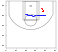

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Rectangle, Circle

filtered_events = filter_candidate_events(dataset['train'])

event = next(iter(filtered_events))
print(event['gameid'])
print(event['event_info']['id'])
print(event['event_info']['desc_home'])
print(event['event_info']['desc_away'])

screen_start = event['event_info']['screen_frame_start']
screen_end = event['event_info']['screen_frame_end'] + 30

fig, ax = plt.subplots(figsize=(4, 4), dpi = 16)

# from screen to 1 sec after screen
for moment in event['moments'][screen_start:screen_end]:

    for player_coord in moment['player_coordinates']:
        if player_coord['playerid'] == event['event_info']['handler_id']:
          c = 'r'
        elif player_coord['playerid'] == event['event_info']['screener_id']:
          c = 'b'
        else:
          continue
        plt.plot(player_coord['x'], player_coord['y'], 'o', markersize=3, color=c)

    # ball_x = moment['ball_coordinates']['x']
    # ball_y = moment['ball_coordinates']['y']
    # plt.plot(ball_x, ball_y, 'o', markersize=1, color='k')

lw = 1
color = 'black'
hoop = Circle((25, 89.25), radius=.85, linewidth=lw, color=color, fill=False)

outer_box = Rectangle((17, 75), 16, 19, linewidth=lw, color=color,
                      fill=False)

inner_box = Rectangle((19, 75), 12, 19, linewidth=lw, color=color,
                      fill=False)

top_free_throw = Arc((25, 75), 12, 12, theta1=180, theta2=0,
                      linewidth=lw, color=color, fill=False)

bottom_free_throw = Arc((25, 75), 12, 12, theta1=0, theta2=180,
                        linewidth=lw, color=color, linestyle='dashed')

corner_three_a = Rectangle((3, 80), 0, 14, linewidth=lw,
                            color=color)
corner_three_b = Rectangle((47, 80), 0, 14, linewidth=lw, color=color)
three_arc = Arc((25, 89.25), 47.5, 47.5, theta1=202, theta2=337.5, linewidth=lw,
                color=color)

court_elements = [hoop, outer_box, inner_box, top_free_throw,
                  bottom_free_throw, corner_three_a,
                  corner_three_b, three_arc]

for element in court_elements:
    ax.add_patch(element)

plt.xlim(0, 50)
plt.ylim(47, 94)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

Now, we will save the generated images in a google drive folder for later access.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Rectangle, Circle

filtered_events = filter_candidate_events(dataset['train'])

event_prior_stamp_start = 0

for event in filtered_events:
  if event['event_info']['screen_time_stamps'][0] == event_prior_stamp_start:
      continue

  fig, ax = plt.subplots(figsize=(4, 4), dpi = 16)

  screen_start = event['event_info']['screen_frame_start']
  screen_end = event['event_info']['screen_frame_end'] + 30

  # from screen to 1 sec after screen
  for moment in event['moments'][screen_start:screen_end]:

      for player_coord in moment['player_coordinates']:
          if player_coord['playerid'] == event['event_info']['handler_id']:
            c = 'r'
          elif player_coord['playerid'] == event['event_info']['screener_id']:
            c = 'b'
          else:
            continue
          plt.plot(player_coord['x'], player_coord['y'], 'o', markersize=3, color=c)

      # ball_x = moment['ball_coordinates']['x']
      # ball_y = moment['ball_coordinates']['y']
      # plt.plot(ball_x, ball_y, 'o', markersize=1, color='k')

  event_prior_stamp_start = event['event_info']['screen_time_stamps'][0]
  lw = 1
  color = 'black'
  hoop = Circle((25, 89.25), radius=.85, linewidth=lw, color=color, fill=False)

  outer_box = Rectangle((17, 75), 16, 19, linewidth=lw, color=color,
                        fill=False)

  inner_box = Rectangle((19, 75), 12, 19, linewidth=lw, color=color,
                        fill=False)

  top_free_throw = Arc((25, 75), 12, 12, theta1=180, theta2=0,
                        linewidth=lw, color=color, fill=False)

  bottom_free_throw = Arc((25, 75), 12, 12, theta1=0, theta2=180,
                          linewidth=lw, color=color, linestyle='dashed')

  corner_three_a = Rectangle((3, 80), 0, 14, linewidth=lw,
                              color=color)
  corner_three_b = Rectangle((47, 80), 0, 14, linewidth=lw, color=color)
  three_arc = Arc((25, 89.25), 47.5, 47.5, theta1=202, theta2=337.5, linewidth=lw,
                  color=color)

  court_elements = [hoop, outer_box, inner_box, top_free_throw,
                    bottom_free_throw, corner_three_a,
                    corner_three_b, three_arc]

  for element in court_elements:
      ax.add_patch(element)

  plt.xlim(0, 50)
  plt.ylim(47, 94)
  plt.gca().set_aspect('equal', adjustable='box')
  plt.savefig('event_images/' + event['gameid'] + "_" + event['event_info']['id'] + ".png")
  plt.clf()
  plt.close();

### Creating Event Features ###

The other feature set for classification will be derived features that are extracted from the tracking data. This won't be images, but they will be coordinates of the handler and screener at the start and end of play, the average velocity across the play, the distance covered by the handler and screener, and finally the position of the handler and screener.

In [ ]:
import pandas as pd
import numpy as np

def play_feature_csv_generator(filter_dict):
  from math import dist

  event_prior_stamp_start = 0

  handler_position = []
  screener_position = []
  handler_distance = []
  screener_distance = []
  handler_avg_velo = []
  screener_avg_velo = []
  handler_start_x = []
  handler_start_y = []
  screener_start_x = []
  screener_start_y = []
  handler_end_x = []
  handler_end_y = []
  screener_end_x = []
  screener_end_y = []

  for event in filter_dict:
    if event['event_info']['screen_time_stamps'][0] == event_prior_stamp_start:
        continue

    handler_id = event['event_info']['handler_id']
    screener_id = event['event_info']['screener_id']

    for player in (event['visitor']['players'] + event['home']['players']):
      if player['playerid'] == handler_id:
        handler_pos = player['position']
        handler_position.append(handler_pos)
      elif player['playerid'] == screener_id:
        screener_pos = player['position']
        screener_position.append(screener_pos)

    action_start = event['event_info']['screen_frame_start']
    action_end = min(len(event['moments']) - 1, event['event_info']['screen_frame_end'] + 30)

    initial_locations = event['moments'][action_start]['player_coordinates']

    if len(initial_locations) == 0:
      initial_locations = event['moments'][action_start+1]['player_coordinates']

    handler_start_loc = [[d['x'], d['y']] for d in initial_locations if d['playerid'] == handler_id][0]
    screener_start_loc = [[d['x'], d['y']] for d in initial_locations if d['playerid'] == screener_id][0]

    handler_start_x.append(handler_start_loc[0])
    handler_start_y.append(handler_start_loc[1])
    screener_start_x.append(screener_start_loc[0])
    screener_start_y.append(screener_start_loc[1])

    handler_loc = handler_start_loc
    screener_loc = screener_start_loc

    hstep_distances = []
    sstep_distances = []
    hstep_velos = []
    sstep_velos = []
    for moment in event['moments'][action_start:action_end]:
      if len([[d['x'], d['y']] for d in moment['player_coordinates'] if d['playerid'] == handler_id]) == 0:
        handler_current_pos = handler_loc
      else:
        handler_current_pos = [[d['x'], d['y']] for d in moment['player_coordinates'] if d['playerid'] == handler_id][0]
      if len([[d['x'], d['y']] for d in moment['player_coordinates'] if d['playerid'] == screener_id]) == 0:
        screener_current_pos = screener_loc
      else:
        screener_current_pos = [[d['x'], d['y']] for d in moment['player_coordinates'] if d['playerid'] == screener_id][0]

      # distance covered at this step
      handler_step_distance = dist(handler_loc, handler_current_pos)
      hstep_distances.append(handler_step_distance)

      screener_step_distance = dist(screener_loc, screener_current_pos)
      sstep_distances.append(screener_step_distance)

      # velocity at this step, .04 seconds btwn each frame
      handler_step_velocity = handler_step_distance / .04
      hstep_velos.append(handler_step_velocity)

      screener_step_velocity = screener_step_distance / .04
      sstep_velos.append(screener_step_velocity)

      # add to lists and update locs
      handler_loc = handler_current_pos
      screener_loc = screener_current_pos

    handler_distance.append(sum(hstep_distances))
    screener_distance.append(sum(sstep_distances))

    handler_avg_velo.append(np.mean(hstep_velos))
    screener_avg_velo.append(np.mean(sstep_velos))

    handler_end_loc = handler_loc
    screener_end_loc = screener_loc

    handler_end_x.append(handler_end_loc[0])
    handler_end_y.append(handler_end_loc[1])
    screener_end_x.append(screener_end_loc[0])
    screener_end_y.append(screener_end_loc[1])

    event_prior_stamp_start = event['event_info']['screen_time_stamps'][0]

  df_dict = {
      'handler_position': handler_position,
      'screener_position': screener_position,
      'handler_distance': handler_distance,
      'screener_distance': screener_distance,
      'handler_avg_velo': handler_avg_velo,
      'screener_avg_velo': screener_avg_velo,
      'handler_start_x': handler_start_x,
      'handler_start_y': handler_start_y,
      'screener_start_x': screener_start_x,
      'screener_start_y': screener_start_y,
      'handler_end_x': handler_end_x,
      'handler_end_y': handler_end_y,
      'screener_end_x': screener_end_x,
      'screener_end_y': screener_end_y
  }

  return pd.DataFrame(df_dict)

In [ ]:
filtered_events = filter_candidate_events(dataset['train'])
tabular_features = play_feature_csv_generator(filtered_events)
tabular_features.to_csv('play_features.csv')

### Labeling the Data ###

Since this data is solely the coordinates and play-by-play data, we need to label the candidate events by if they are pick-and-roll, pick-and-pop or nothing. We could do this within python, but it will be easier to extract a csv, open it in Google Sheets or Excel, add a label column and manually create a label based on film of each event and plotting the moment of screen (using above plot format).

The film of each event can be obtained in a link of the following format:
- https://www.nba.com/game/mia-vs-ind-0021500333/play-by-play

The features extracted in the following csv also help for event identification, as the game clock, handler name, and screener name all help for visual identification.

In [ ]:
# save csv of game ids, handler and screener name (to match events), event number, and description
# so that it can be input directly to an excel file
import pandas as pd
import numpy as np

def play_csv_generator(filter_dict):
    game_id = []
    event_number = []
    event_desc = []
    handler_name = []
    screener_name = []
    start_time = []

    event_prior_stamp_start = 0

    for event in filter_dict:
        if event['event_info']['screen_time_stamps'][0] == event_prior_stamp_start:
            continue

        start_time.append(event['event_info']['screen_time_stamps'][0])
        game_id.append(event['gameid'])
        event_number.append(event['event_info']['id'])
        event_desc.append(event['event_info']['desc_home'] + " / " + event['event_info']['desc_away'])

        for player in (event['visitor']['players'] + event['home']['players']):
            if event['event_info']['handler_id'] == player['playerid']:
                handler_name.append(player['firstname'] + " " + player['lastname'])
            elif event['event_info']['screener_id'] == player['playerid']:
                screener_name.append(player['firstname'] + " " + player['lastname'])
        event_prior_stamp_start = event['event_info']['screen_time_stamps'][0]

    return pd.DataFrame({
        'game_id': game_id,
        'event_number': event_number,
        'start_time': start_time,
        'event_desc': event_desc,
        'handler_name': handler_name,
        'screener_name': screener_name
    })

filtered_events = filter_candidate_events(dataset['train'])
new_info = play_csv_generator(filtered_events)

In [ ]:
new_info.to_csv('potential_screens.csv')

### Image Classification ###

Once pre-processing, feature engineering, and event labelling has been completed, we can begin modeling. The first method that will be explored is image classification. Since there are small, hard-to-discern differences between these images and there are relatively few images in the training set (less than 200 after split), I chose to try a Random Forest and SVM for image classification. I specifically did not choose a Neural Network, there weren't enough samples to accurately train.

In [ ]:
import pandas as pd
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV

event_images_path = 'nba_tracking_data_15_16/event_images'
event_info = pd.read_csv('nba_tracking_data_15_16/potential_screens.csv')
labels = []
images = []

for index, row in event_info.iterrows():
    img_name = os.path.join(event_images_path, row['image_paths'])
    img = cv2.imread(img_name)
    img_flattened = img.flatten()  # Flatten the image into a 1D array
    images.append(img_flattened)
    labels.append(row['label'])

X = np.array(images)
y = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29, stratify = y)

In [ ]:
svm_image_classifier = SVC(probability = True)

param_grid = {'C': [0.1, .5, 1, 5, 10], 'gamma': [.01, .1, 1], 'kernel': ['linear', 'poly', 'rbf']}

grid_search = GridSearchCV(svm_image_classifier, param_grid, refit = True, scoring = "f1_weighted", cv=5)
grid_search.fit(X_train, y_train)

svm_best_params = grid_search.best_params_
print(svm_best_params)

{'C': 0.1, 'gamma': 0.01, 'kernel': 'poly'}


In [ ]:
rf_image_classifier = RandomForestClassifier()

param_grid = {'n_estimators': [10, 50, 100, 500], 'max_features': [None, 'sqrt', 'log2'], 'min_samples_split': [2, 4, 6]}

grid_search = GridSearchCV(rf_image_classifier, param_grid, refit = True, scoring = "f1_weighted", cv=5)
grid_search.fit(X_train, y_train)

rf_best_params = grid_search.best_params_
print(rf_best_params)

{'max_features': 'log2', 'min_samples_split': 6, 'n_estimators': 50}


In [ ]:
svm_image_classifier = SVC(C = svm_best_params['C'], gamma = svm_best_params['gamma'], kernel = svm_best_params['kernel'], probability = True)
rf_image_classifier = RandomForestClassifier(n_estimators = rf_best_params['n_estimators'], max_features = rf_best_params['max_features'], min_samples_split = rf_best_params['min_samples_split'])

svm_image_classifier.fit(X_train, y_train)
rf_image_classifier.fit(X_train, y_train)

svm_pred = svm_image_classifier.predict(X_test)
rf_pred = rf_image_classifier.predict(X_test)

print(f"SVM Image Classification Accuracy: {round(accuracy_score(y_test, svm_pred), 4)}")
print(f"SVM F1 Weighted Score: {round(f1_score(y_test, svm_pred, average = 'weighted'), 4)}")

print(f"RF Image Classification Accuracy: {round(accuracy_score(y_test, svm_pred), 4)}")
print(f"RF F1 Weighted Score: {round(f1_score(y_test, rf_pred, average = 'weighted'), 4)}")

SVM Image Classification Accuracy: 0.5227
SVM F1 Weighted Score: 0.4983
RF Image Classification Accuracy: 0.5227
RF F1 Weighted Score: 0.5189


The output of both SVM image classification and Random Forest image classification is not inspiring. The rather low scores prove this at around 50% accuracy and F1 score for both methods.

-----------

### Using Engineered Features ###

The image classification was not a successful endeavor, but we can try using the csv of engineered features we created earlier to attempt greater success.


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# load the data
play_features = pd.read_csv('nba_tracking_data_15_16/play_features.csv')

# drop irrelevant column
play_features = play_features.drop(['Unnamed: 0'], axis = 1)

# OHE handler_position and screener_position
positions = play_features[['handler_position', 'screener_position']].copy()
# in positions, modify so that G-F = F-G and F-C = C-F
positions = positions.replace({'F-G': 'G-F', 'C-F': 'F-C'})

encoder = OneHotEncoder(sparse_output = False)
encoded_positions = pd.DataFrame(encoder.fit_transform(positions), columns = encoder.get_feature_names_out())
play_features = play_features.drop(['handler_position', 'screener_position'], axis = 1)
play_features = pd.concat([play_features, encoded_positions], axis = 1)

play_features.head()
# standardize numerical features
numerical = play_features[play_features.columns[:12]]
scaler = StandardScaler()
play_features[play_features.columns[:12]] = scaler.fit_transform(numerical)

play_features.head()

,handler_distance,screener_distance,handler_avg_velo,screener_avg_velo,handler_start_x,handler_start_y,screener_start_x,screener_start_y,handler_end_x,handler_end_y,...,handler_position_C,handler_position_F,handler_position_F-C,handler_position_G,handler_position_G-F,screener_position_C,screener_position_F,screener_position_F-C,screener_position_G,screener_position_G-F
0,-1.643483,1.612936,-1.593351,1.847579,0.914089,2.178985,1.391632,1.590210,0.980849,1.616014,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.966879,3.280209,-1.116972,2.741370,1.132512,0.737087,1.349950,0.714861,0.818935,-1.135463,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.905280,0.418506,0.711958,0.313831,0.308786,-1.097858,0.167329,-0.949175,-0.563238,0.142802,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.032158,-0.408997,0.203004,-0.209677,1.232351,-0.042941,1.248219,0.247638,1.352846,0.964804,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.093847,-0.783444,-0.846935,-0.515225,0.218305,-1.290789,0.269808,-1.104495,-0.041792,-1.513329,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
# train-test split
X = play_features.loc[:, play_features.columns != 'label']
y = play_features['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29, stratify = y)

With the engineered features, we will try penalized logistic regression, a support vector machine, and an xgBoost model. This provides a range of model types to try out.

In [ ]:
from sklearn.linear_model import LogisticRegression

param_grid = {'penalty': ['l1', 'l2'], 'C': [.01, .1, .5, 1, 2, 5, 10]}

# f1_weighted chosen to account for multiclass and label imbalance
log_grid_search = GridSearchCV(LogisticRegression(solver = 'liblinear'), param_grid, scoring = 'f1_weighted', cv=5)
log_grid_search.fit(X_train, y_train)

log_best_params = log_grid_search.best_params_
print(log_best_params)

{'C': 1, 'penalty': 'l2'}


In [ ]:
param_grid = {'C': [0.1, .5, 1, 5, 10], 'gamma': [.01, .1, 1], 'kernel': ['linear', 'poly', 'rbf']}

svm_grid_search = GridSearchCV(SVC(probability = True), param_grid, refit = True, scoring = "f1_weighted", cv=5)
svm_grid_search.fit(X_train, y_train)

svm_best_params = svm_grid_search.best_params_
print(svm_best_params)

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder

# encode y labels
y_encoder = LabelEncoder()
y_train_encoded = y_encoder.fit_transform(y_train)

# create a range of parameters to search over
param_distribution = {
    "max_depth": np.arange(0, 10),
    "eta": np.arange(.1, .6, .1),
    "n_estimators": np.arange(10, 500, 10),
    "subsample": np.arange(.1, 1.1, .1),
    'min_child_weight': np.arange(1, 5, 1)
}

# use random search for 12 iterations [arbitrary but reasonable]
xgb_random_search = RandomizedSearchCV(XGBClassifier(objective="multi:softprob"), param_distribution, n_iter = 12, scoring = 'f1_weighted', cv = 5, random_state = 29)
xgb_random_search.fit(X_train, y_train_encoded)

xgb_best_params = xgb_random_search.best_params_
print(xgb_best_params)

{'subsample': 1.0, 'n_estimators': 460, 'min_child_weight': 2, 'max_depth': 5, 'eta': 0.1}


In [ ]:
from sklearn.metrics import roc_auc_score
# train models
log_model = LogisticRegression(C = log_best_params['C'], penalty = log_best_params['penalty'], solver = 'liblinear')
svm_model = SVC(C = svm_best_params['C'], gamma = svm_best_params['gamma'], kernel = svm_best_params['kernel'], probability = True)
xgb_model = XGBClassifier(objective = "multi:softprob", max_depth = xgb_best_params['max_depth'], eta = xgb_best_params['eta'], n_estimators = xgb_best_params['n_estimators'], subsample = xgb_best_params['subsample'], min_child_weight = xgb_best_params['min_child_weight'])

log_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train_encoded)

# compare test scores across metrics
print(f"Penalized Logistic Regression Accuracy: {round(log_model.score(X_test, y_test), 4)}")
print(f"Penalized Logistic Regression F1 Weighted Score: {round(f1_score(y_test, log_model.predict(X_test), average = 'weighted'), 4)}")
print(f"Penalized Logistic Regression ROC AUC Score: {round(roc_auc_score(y_test, log_model.predict_proba(X_test), multi_class = 'ovr'), 4)} \n")

print(f"SVM Accuracy: {round(svm_model.score(X_test, y_test), 4)}")
print(f"SVM F1 Weighted Score: {round(f1_score(y_test, svm_model.predict(X_test), average = 'weighted'), 4)}")
print(f"SVM ROC AUC Score: {round(roc_auc_score(y_test, svm_model.predict_proba(X_test), multi_class = 'ovr'), 4)} \n")

y_test_encoded = y_encoder.transform(y_test)
print(f"XGBoost Accuracy: {round(accuracy_score(y_test_encoded, xgb_model.predict(X_test)), 4)}")
print(f"XGBoost F1 Weighted Score: {round(f1_score(y_test_encoded, xgb_model.predict(X_test), average = 'weighted'), 4)}")
print(f"XGBoost ROC AUC Score: {round(roc_auc_score(y_test_encoded, xgb_model.predict_proba(X_test), multi_class = 'ovr'), 4)}")

Penalized Logistic Regression Accuracy: 0.8409
Penalized Logistic Regression F1 Weighted Score: 0.8352
Penalized Logistic Regression ROC AUC Score: 0.8787 

SVM Accuracy: 0.7955
SVM F1 Weighted Score: 0.7919
SVM ROC AUC Score: 0.8953 

XGBoost Accuracy: 0.7727
XGBoost F1 Weighted Score: 0.7608
XGBoost ROC AUC Score: 0.8862


Surprisingly, penalized logistic regression (in this case ridge with C = 1) outperformed the other models in accuracy and F1 score. It only performed slightly worse in ROC-AUC score, with which they all performed similarly. This 84% test accuracy indicates that there is confidence in the model to correctly classify the action based given candidates as inputs.

### Real-World Application and Interest ###
Using this pipeline, from raw coordinate and play-by-play data, actions can be identified and then watched by coaches and staff. This can aid scouting and development.

For example, if a coach wanted to watch how a player performed every time they were the ball-handler in the pick-and-roll, the events for the last n games could be processed and potential PNR events could be output. Then the coach can use game film to go back and watch them without having to watch the whole game looking out for these situations.

Similarly, if a scout wanted to understand how another team's center operated, they could run the pipeline for all events where the player is in the game and a screener and understand the proportion of pick and rolls to pick and pops.

While the outputs may not be entirely correct, as we only achieved 84% accuracy, there is little penalty to incorrectly identifying some events, and much reward to correctly identifying the majority. This is because a subsample of correct events can still inform behavior while little extra may be gleaned from the misclassified ones.